<a href="https://colab.research.google.com/github/22f2000792/MLP-prac/blob/main/week_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [254]:
import pandas as pd
import numpy as np
path='https://archive.ics.uci.edu/ml/machine-learning-databases/00488/Live_20210128.csv'

In [255]:
df=pd.read_csv(path)
df.head(3)

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN


In [256]:
df.shape

(7050, 16)

Check if any feature contains Null values.

Drop all the features which have Null values.

Save 'status_type' as target variable.

Drop the feature "status_id", "status_type" and "status_published" from training set.

Use LabelEncoder to transform the target variable.


In [257]:
df.isnull().sum()

,0
status_id,0
status_type,0
status_published,0
num_reactions,0
num_comments,0
num_shares,0
num_likes,0
num_loves,0
num_wows,0
num_hahas,0


In [258]:
df=df.dropna(axis=1)

In [259]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   status_id         7050 non-null   int64 
 1   status_type       7050 non-null   object
 2   status_published  7050 non-null   object
 3   num_reactions     7050 non-null   int64 
 4   num_comments      7050 non-null   int64 
 5   num_shares        7050 non-null   int64 
 6   num_likes         7050 non-null   int64 
 7   num_loves         7050 non-null   int64 
 8   num_wows          7050 non-null   int64 
 9   num_hahas         7050 non-null   int64 
 10  num_sads          7050 non-null   int64 
 11  num_angrys        7050 non-null   int64 
dtypes: int64(10), object(2)
memory usage: 661.1+ KB


In [260]:
df.head(3)

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0


In [261]:
df.status_type.nunique()

4

In [262]:
feature=df.drop(columns=['status_type','status_id','status_published'],axis=1)
label=df['status_type'].copy()


In [263]:
feature.head()

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,529,512,262,432,92,3,1,1,0
1,150,0,0,150,0,0,0,0,0
2,227,236,57,204,21,1,1,0,0
3,111,0,0,111,0,0,0,0,0
4,213,0,0,204,9,0,0,0,0


In [264]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
label=le.fit_transform(label)

In [265]:
np.unique(label)

array([0, 1, 2, 3])

In [266]:
np.unique_counts(label)

UniqueCountsResult(values=array([0, 1, 2, 3]), counts=array([  63, 4288,  365, 2334]))

In [267]:
## pd.DataFrame(label).value_counts()

In [268]:
from sklearn.preprocessing import StandardScaler
sca=StandardScaler().set_output(transform='pandas')

In [269]:
feature=sca.fit_transform(feature)

In [270]:
for col_ in feature.columns:
    print(np.var(feature[col_]))

1.000000000000033
1.0000000000000073
0.9999999999999764
0.999999999999988
1.0000000000000318
1.0000000000000717
0.9999999999998975
1.00000000000011
0.9999999999999776


In [271]:
from sklearn.cluster import  KMeans
km=KMeans(n_clusters=2,random_state=0)

In [272]:
km.fit(feature,label)

KMeans(n_clusters=2, random_state=0)

In [273]:
km.inertia_

48278.0982422049

In [274]:
km.set_params(n_clusters=4)

KMeans(n_clusters=4, random_state=0)

In [275]:
km.fit(feature,label)

KMeans(n_clusters=4, random_state=0)

In [276]:
km_pre=km.predict(feature)

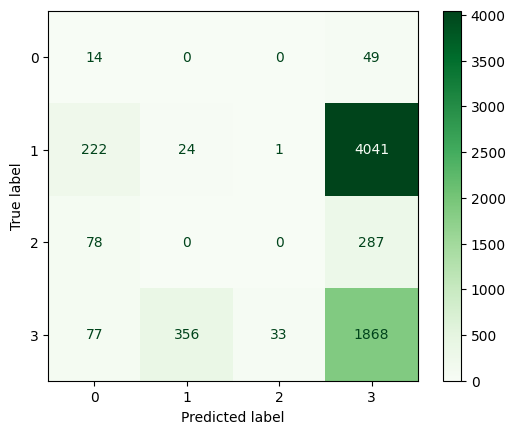

In [277]:
from sklearn.metrics import  confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

con=confusion_matrix(label,km_pre)
ConfusionMatrixDisplay(con).plot(cmap='Greens')
plt.show()

In [278]:
s = np.sum(label == km_pre)
print(f"Number of matches: {s}")

Number of matches: 1906


For Q6,Q7,Q8 Train the model using Agglomerative Clustering by setting the parameter as following:
- n_clusters=4,affinity='euclidean', linkage='ward'

In [279]:
from sklearn.cluster import  AgglomerativeClustering
amc=AgglomerativeClustering(n_clusters=4,metric='euclidean',linkage='ward')
amc_cluster=amc.fit(feature,label)

In [280]:
amc_cluster

AgglomerativeClustering(n_clusters=4)

In [281]:
amc_cluster.labels_

array([3, 3, 3, ..., 3, 3, 3])

In [282]:
amc_cluster.n_leaves_

7050

In [287]:
from sklearn.metrics import  accuracy_score
accuracy_score(label,amc_cluster.fit_predict(feature))*100

28.496453900709216